In [1]:
# Uncomment and run this cell if you're on Colab or Kaggle
# !git clone https://github.com/nlp-with-transformers/notebooks.git
# %cd notebooks
# from install import *
# install_requirements()

In [2]:
# hide
from utils import *
setup_chapter()

Using transformers v4.57.1
Using datasets v5.0.0


# Text Generation

<img alt="LM Meta Learning" width="800" caption="During pretraining, language models are exposed to sequences of tasks that can be adapted during inference (courtesy of Tom B. Brown)" src="images/chapter05_lm-meta-learning.png" id="lm-meta-learning"/>

<img alt="Meena" width="300" caption="Meena on the left telling a corny joke to a human on the right (courtesy of Daniel Adiwardana and Thang Luong)" src="images/chapter05_meena.png" id="meena"/>

## The Challenge with Generating Coherent Text

<img alt="Text generation" width="700" caption="Generating text from an input sequence by adding a new word to the input at each step" src="images/chapter05_text-generation.png" id="text-generation"/> 

## Greedy Search Decoding

In [3]:
# hide_output
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
# AutoTokenizer -> carga el tokenizador adecuado para el modelo
# AutoModelForCausalLM carga un modelo preparado para generación de texto

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2-xl" # el modelo que quiero usar
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

AutoModelForCausalLM hace internamente

if model_name == "gpt2-xl":
    return GPT2LMHeadModel(...)
    

elif model_name == "facebook/opt-1.3b":
    return OPTForCausalLM(...)
    

elif model_name == "meta-llama/Llama-3.1-8B":
    return LlamaForCausalLM(...)
    

elif model_name == "Qwen/Qwen3-8B":
    return QwenForCausalLM(...)

En esta celda se implementa manualmente el proceso de generación autoregresiva. Es decir, hace paso a paso lo que después hará model.generate() automáticamente.

In [4]:
# hide_output
import pandas as pd

input_txt = "Transformers are the" # Texto inicial
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device) # tokeniza y convierte el texto en un tensor de IDs. Selecciona IDs y los pasa a GPU, donde está el modelo.
iterations = []
n_steps = 8 # queremos generar 8 tokens
choices_per_step = 5 # en cada paso queremos ver los 5 tokens más probables. No elegirlos sino mostrarlos

with torch.no_grad(): # no entrenamos, sólo inferencia
    for _ in range(n_steps): # se ejecutará 8 veces
        iteration = dict() # en este diccionario vacío se almacenará choice 1, choice 2... choice 5
        iteration["Input"] = tokenizer.decode(input_ids[0])
        # Añade la clave (columna) "Input" al diccionario iteration
        # input_ids es un tensor que contiene esto tensor([[41762, 389, 262]]) -> 2 corchetes-> shape =(batch, longitud sec)
        # en este casoshape (1,3)
        # input_ids[0] -> Primera y última secuencia del batch
        # tokenizer.decode() -> pasa de número a texto (proceso inverso)
        
        output = model(input_ids=input_ids) # el Transformer recibe  el input_ids y produce logits -> puntuaciomes
        # shape de los logits (batch, longitud, vocabulario) -> Por ejemplo (1,3,50257) en GPT 2 vocabulario es de 50257 palabras
        # Select logits of the first batch and the last token and apply softmax
        next_token_logits = output.logits[0, -1, :] # elige primer(y único) batch, último token de la secuancia, puntuaciones de TODO elvocabulario
        next_token_probs = torch.softmax(next_token_logits, dim=-1) # aplica softmax (logits->probabilidades) sobre la última dimensión (probabilidades)
        sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True) # ordena tokens desde el más probable al menos probable
        # Store tokens with highest probabilities / Mostramos las 5 mejores opciones
        for choice_idx in range(choices_per_step):
            token_id = sorted_ids[choice_idx] # tomamos los primeros tokens ids
            token_prob = next_token_probs[token_id].cpu().numpy() #tomamos la probabilidad de los tokens seleccionados 
            # y lo enviamos a la cpu para convertirlos de tensores a numpy array
            token_choice = (
                f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)") # Muestra el nombre del token elegido (% probabilidad)
            
            iteration[f"Choice {choice_idx+1}"] = token_choice # añade una columna x iteración e incluye info de toke choice
        # Append predicted next token to input
        input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
        # sorted_ids -> shape(50257,)
        # sorted_ids[0] selecciona el id con más probabilidad.  Es un númeri, tienen shape [[]], así que no tiene dimensión  ()
        # sorted_ids es elID deltoken más probable, pero tendría shape escalar ()
        # para concatenarlo con con input_ids necesitamos forma (1,1), porque input_ids tiene forma (batch, longitud)
        # sorted_ids[None,0, None] -> Añade otra dimensión detrás -> Añade una dimensión delante y otra detrás: 2 dimensiones (1,1)
        # ahora sorted_ids tiene las mismas dimensiones que que input_ids: 2 dimensiones -> Puedo concatenar
        # torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1) -> conactena ambos elementos en la última dimensión que es la longitd de secuencia:
            # en el caso de input_ids es la primera frase (prompt )
            # en el caso de sorted_ids son  los ids predichos en cada iteración
            # el contenido de ambos forma el contexto
        iterations.append(iteration)
        # añade el diccionario de esta iteración a la lista iterations.
        
pd.DataFrame(iterations)
# crea el detaframe a partir del DF

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Transformers are the,most (8.53%),only (4.96%),best (4.65%),Transformers (4.37%),ultimate (2.16%)
1,Transformers are the most,popular (16.78%),powerful (5.37%),common (4.96%),famous (3.72%),successful (3.20%)
2,Transformers are the most popular,toy (10.63%),toys (7.23%),Transformers (6.60%),of (5.46%),and (3.76%)
3,Transformers are the most popular toy,line (34.38%),in (18.20%),of (11.71%),brand (6.10%),line (2.69%)
4,Transformers are the most popular toy line,in (46.28%),of (15.09%),", (4.94%)",on (4.40%),ever (2.72%)
5,Transformers are the most popular toy line in,the (65.99%),history (12.42%),America (6.91%),Japan (2.44%),North (1.40%)
6,Transformers are the most popular toy line in the,world (69.26%),United (4.55%),history (4.29%),US (4.23%),U (2.30%)
7,Transformers are the most popular toy line in ...,", (39.73%)",. (30.64%),and (9.87%),with (2.32%),today (1.74%)


Siguiente celda: Este código hace exactamente lo mismo que el bloque anterior, pero utilizando la **función generate() de Hugging Face**, que automatiza todo el proceso.

In [5]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output = model.generate(input_ids, max_new_tokens=n_steps, do_sample=False)
# Si pusiéramos do_sample = true ->Ya no eligiría el token más probable -> tecnicas de muestreo (veremos depués)
print(tokenizer.decode(output[0]))
# output tiene shape (batch, longitud_total) -> sleccionamos primer batch

Transformers are the most popular toy line in the world,


**generate() hace todo esto**:

```text
input_ids
     ↓
Transformer
     ↓
logits
     ↓
softmax
     ↓
ordenar probabilidades
     ↓
elegir el mejor token
     ↓
añadirlo al contexto
     ↓
repetir
```

In [6]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, 
                               do_sample=False)
print(tokenizer.decode(output_greedy[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The researchers, from the University of California, Davis, and the University of
Colorado, Boulder, were conducting a study on the Andean cloud forest, which is
home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to
communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able


## Beam Search Decoding

<img alt="Beam search" width="700" caption="Beam search with two beams—the most probable sequences at each timestep are highlighted in blue" src="images/chapter05_beam-search.png" id="beam-search"/> 

In [7]:
0.5 ** 1024

5.562684646268003e-309

In [8]:
import numpy as np

sum([np.log(0.5)] * 1024)

np.float64(-709.7827128933695)

In [11]:
import torch.nn.functional as F

def log_probs_from_logits(logits, labels): 
    # logits -> salida del transformer
    # labels -> Los ID's de los tokens correctos o seleccionados
    logp = F.log_softmax(logits, dim=-1) # forma: (batch, longitud, vocabulario)
    logp_label = torch.gather(logp, 2, labels.unsqueeze(2)).squeeze(-1)
    
    return logp_label

    # logp -> forma: (batch, longitud, vocabulario). 
        #En cada posición de longitud -> log-probabilidad para cada token del vocabulario
        #logp = [
        #       [
        #           [-2.0, -0.5, -3.0, -1.2, -4.0],  # posición 0
        #           [-1.0, -2.5, -0.3, -3.0, -4.0],  # posición 1
        #           [-3.0, -1.5, -2.0, -0.2, -4.0]   # posición 2
        #       ]
        #   ]
    
    # labels -> forma:(batch, longitud) 
        # p.ej labels = [[1, 2, 3]] en posic. 0 -> nos interesa token con ID1, en posic.1 -> token con ID2...
    # por lo tanto queremos obtener [[-0.5, -0.3, -0.2]] -> esto es lo que hace torch.gather
    # "2" -> la dimensión en la que vamos a buscar en logp -> "vocabulario" 
        # Para cada elemento del batch y para cada posición, 
        # ve a la dimensión del vocabulario y recoge el token cuyo índice te indique labels.
    #labels.unsqueeze(2):
        # Según doc de torch: ele tensor de índices (labels) tiene que tener el mismo número de dimensiones
        # que el tensor del que queremos extraer valores
        # Ahora:
            # logp -> forma: (batch, longitud, vocabulario). 3 Dimensiones
            # labels -> forma: (batch, longitud). 2 Dimensiones
        # Entonces:
            # dentro del gather subimos una dimensión ( la tercera -posición 2-) para que ambos tensores tengan mismo número de dimensiones
            # fuera del gather hago unsqueeze de la última dimensión de logp_label porque no me hace falta
    

In [12]:
# Aquí calculamos log_probabilidades de una secuencia completa -> Lo que necesita Beam Search

def sequence_logprob(model, labels, input_len=0):
# model -> nuestro modelo
# labels -> la secuencia de tokens (IDs)
# input_len -> cuántos tokens pertenecen al prompt inicial y no queremos puntuar
    
    with torch.no_grad(): # inferimos, no calcula gradientes
        output = model(labels) # forward pass
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])
            # en output.logits;
                # todos los batches
                # todas las posiciones excepto la última (:-1) 
                # porque el último token un tiene un siguiente token a predecir
                # todos los tokens del vocabulario
            # en labels:
                # todos los batches
                # No tiene en cuenta la primera posición (1:)
        seq_log_prob = torch.sum(log_probs[:, input_len:])
        # propiedad logarítmica: log(a*b) = log(a)*log(b)
        # torch.sum(log_probs)-> Suma las log-probabilidades de todos los tokens de la secuencia 
        # para obtener la log-probabilidad total de la frase.
        # pero... no toda la frase ha sido generada -> sumamos a partir de input_len (el prompt)
    return seq_log_prob.cpu().numpy()

Vamos a dibujarlo.

Tenemos la frase:

```text
The    cat    sat
```

La entrada al modelo es:

```text
Posición 0    The
Posición 1    cat
Posición 2    sat
```

El modelo produce tres conjuntos de logits:

```text
a    b    c
```

Pero cada uno significa:

```text
a = "¿qué viene después de The?"

b = "¿qué viene después de The cat?"

c = "¿qué viene después de The cat sat?"
```

Por tanto, las comparaciones correctas son:

| Logits | Predicen | Label correcta |
|--------|----------|----------------|
| a | siguiente de "The" | cat |
| b | siguiente de "The cat" | sat |
| c | siguiente de "The cat sat" | `<eos>` (o el siguiente token si existe) |

Ahora aplicamos los *slices*.

### Logits

```python
output.logits[:, :-1, :]
```

Nos quedamos con:

```text
a
b
```

### Labels

```python
labels[:, 1:]
```

Nos quedamos con:

```text
cat
sat
```

Entonces el emparejamiento es exactamente:

```text
a  → cat

b  → sat
```

No es:

```text
cat → a

sat → b
```

aunque conceptualmente estés diciendo lo mismo.

Lo importante es recordar que:

- **a** es la **predicción** (los *logits* que produce el modelo).
- **cat** es la **respuesta correcta** (*label*) con la que se compara esa predicción.

Una forma de verlo es como un examen:

```text
Pregunta (predicción del modelo): a
Respuesta correcta:              cat

Pregunta (predicción del modelo): b
Respuesta correcta:              sat
```

In [13]:
# Aplicamos estas funciones para calcular pimero la sequence log probability del
# Greedy decoder

logp = sequence_logprob(model, output_greedy, input_len=len(input_ids[0]))

# model: el modelo que generó el texto
# output_greedy: la secuencia completa, es decir, prompt + tokens generados
# input_len=len(input_ids[0]): número de tokens que pertenecen al prompt original. -> Para ignorarlos

print(tokenizer.decode(output_greedy[0]))

# decode espera una única secuencia de IDs -> No un batch por eso: output_greedy[0]
print(f"\nlog-prob: {logp:.2f}")

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The researchers, from the University of California, Davis, and the University of
Colorado, Boulder, were conducting a study on the Andean cloud forest, which is
home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to
communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able

log-prob: -87.43


In [14]:
# Hacemos lo mismo con output_beam

output_beam = model.generate(input_ids, max_length=max_length, num_beams=5, 
                             do_sample=False)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The discovery of the unicorns was made by a team of scientists from the
University of California, Santa Cruz, and the National Geographic Society.


The scientists were conducting a study of the Andes Mountains when they
discovered a herd of unicorns living in a remote, previously unexplored valley,
in the Andes Mountains. Even more surprising to the researchers was the fact
that the unicorns spoke perfect English

log-prob: -55.23


In [15]:
# Para evitar texto repetidos, Tunstala propone imponer un n-gram penalty con el mparámetro no_repeat_ngram_size

# Un n-gram es  una secuencia de n tokens consecutivos.
# al penalizar n_gram de tamaño 2, no puede generar el 2-gram "the cat" si ya lo puso antes
output_beam = model.generate(input_ids, max_length=max_length, num_beams=5, 
                             do_sample=False, no_repeat_ngram_size=2)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The discovery was made by a team of scientists from the University of
California, Santa Cruz, and the National Geographic Society.

According to a press release, the scientists were conducting a survey of the
area when they came across the herd. They were surprised to find that they were
able to converse with the animals in English, even though they had never seen a
unicorn in person before. The researchers were

log-prob: -93.12


```text
Greedy
│
├── Siempre el mejor token.
│
▼
Beam Search
│
├── Explora varios caminos.
├── Sigue siendo determinista.
│
▼
Sampling
│
├── Introduce aleatoriedad.
├── No siempre elige el mejor token.
├── Lo hace según las probabilidades.
```

## Sampling Methods

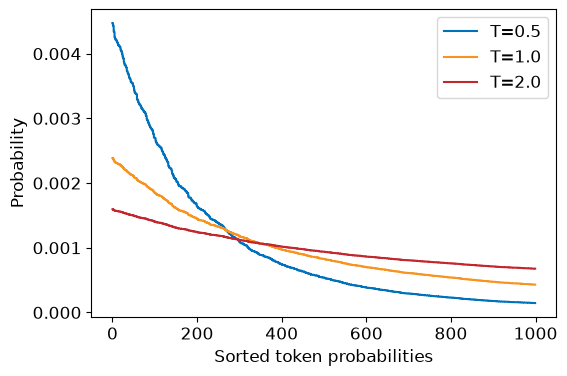

In [16]:
#hide_input

#id temperature
#alt Token probabilities as a function of temperature
#caption Distribution of randomly generated token probabilities for three selected temperatures
import matplotlib.pyplot as plt
import numpy as np

def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [17]:
# hide
torch.manual_seed(42);

In [19]:
# Probamos la salida del modelo con Temperatura = 2  

output_temp = model.generate(input_ids, max_length=max_length, do_sample=True, 
                             temperature=2.0, top_k=0)
print(tokenizer.decode(output_temp[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


Leédockerur's right flank had swesley. Dillon territnton Gokmin NicolDirector
Flaramble BaldKT sealing electrons HarleyBright Monkware Nerfi Foster Lum
related Network Neural Skywolf Bright Ride ConservationCtrie illustCHDBfully
fluids 2008 KDutsche ownpour DA inscription castle shut ZeusDebado beating
Column Chief woes compliance vet BEnvironmental ultimate pictures phones
Filipino East territory Sick Sho Conservative BAS cornerstone cardboard


In [20]:
# hide
torch.manual_seed(42);

In [21]:
# Bajamos la temperatura a 0.5

output_temp = model.generate(input_ids, max_length=max_length, do_sample=True, 
                             temperature=0.5, top_k=0)
print(tokenizer.decode(output_temp[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The scientists were searching for the source of the mysterious sound, which was
making the animals laugh and cry.


The unicorns were living in a remote valley in the Andes mountains

'When we first heard the noise of the animals, we thought it was a lion or a
tiger,' said Luis Guzman, a researcher from the University of Buenos Aires,
Argentina.


'But when


## Top-k and Nucleus Sampling

In [22]:
# hide
torch.manual_seed(42);

In [24]:
# hide
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

In [25]:
# hide
import torch.nn.functional as F

with torch.no_grad():
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = F.softmax(next_token_logits, dim=-1).detach().cpu().numpy()

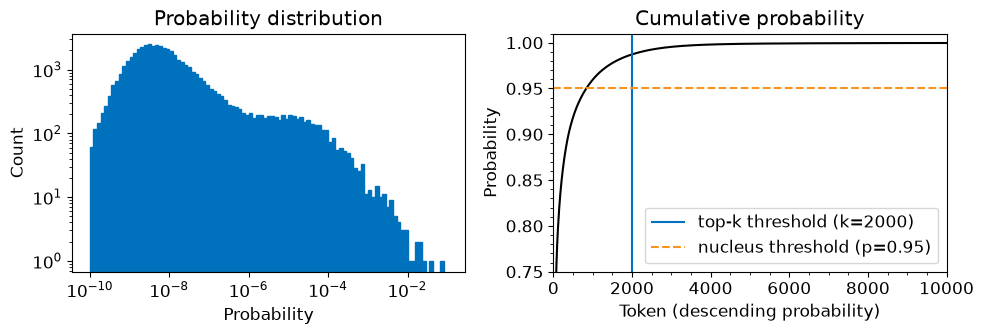

In [26]:
# hide_input

#id distribution
#alt Probability distribution of next token prediction.
#caption Probability distribution of next token prediction (left) and cumulative distribution of descending token probabilities

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 10000])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=2000)'
top_p_label = 'nucleus threshold (p=0.95)'
axes[1].vlines(x=2000, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.95, xmin=0, xmax=10000, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

In [27]:
# hide
torch.manual_seed(42);

In [30]:
# Ejemplo con top_k

output_topk = model.generate(input_ids, max_length=max_length, do_sample=True, 
                             top_k=50)
# top_k=50 -> toma los 50 tokens más probables en cada timestep y los renormaliza para que sumen 1
# sin top K -> 50.257 tokens
# con tok k-> 50 tokens
# los escoge según sus probabilidades
print(tokenizer.decode(output_topk[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The wild unicorns roam the Andes Mountains in the region of Cajamarca, on the
border with Argentina (Picture: Alamy/Ecole Nationale Supérieure d'Histoire
Naturelle)

The researchers came across about 50 of the animals in the valley. They had
lived in such a remote and isolated area at that location for nearly a thousand
years that


In [31]:
# hide
torch.manual_seed(42);

In [32]:
# Ejemplo con top_p

output_topp = model.generate(input_ids, max_length=max_length, do_sample=True, 
                             top_p=0.90)

# toma los tokens que superen la probabilidad acumulada del 90%,  renormalizando -> suma=1
print(tokenizer.decode(output_topp[0]))

In a shocking finding, scientist discovered a herd of unicorns living in a
remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect
English.


The scientists studied the DNA of the animals and came to the conclusion that
the herd are descendants of a prehistoric herd that lived in Argentina about
50,000 years ago.


According to the scientific analysis, the first humans who migrated to South
America migrated into the Andes Mountains from South Africa and Australia, after
the last ice age had ended.


Since their migration, the animals have been adapting to


## Which Decoding Method Is Best?

## Conclusion